In [2]:
print("RELAY-BASED MULTI AGENT DELIVERY SYSTEM")
print("Zomathon Project Simulation")
print("--------------------------------------")

RELAY-BASED MULTI AGENT DELIVERY SYSTEM
Zomathon Project Simulation
--------------------------------------


In [56]:
import heapq
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from IPython.display import HTML

In [4]:
# Delivery corridor locations

locations = ["A","B","C","D","E","F"]

restaurant = "C"

print("Restaurant location:", restaurant)
print("City nodes:", locations)

Restaurant location: C
City nodes: ['A', 'B', 'C', 'D', 'E', 'F']


In [12]:
graph = {

"A":{"B":1},

"B":{"A":1,"C":1},

"C":{"B":1,"D":1},

"D":{"C":1,"E":1},

"E":{"D":1,"F":1},

"F":{"E":1}

}

print("Road Network Created")

Road Network Created


In [13]:
def heuristic(node, goal):

    h_values = {

    "A":5,
    "B":4,
    "C":3,
    "D":2,
    "E":1,
    "F":0

    }

    return h_values[node]

In [14]:
def astar(start, goal):

    queue = [(0,start,[])]

    visited=set()

    while queue:

        cost,node,path = heapq.heappop(queue)

        if node in visited:
            continue

        path = path + [node]

        if node == goal:
            return path

        visited.add(node)

        for next_node,distance in graph[node].items():

            if next_node not in visited:

                priority = cost + distance + heuristic(next_node,goal)

                heapq.heappush(queue,(priority,next_node,path))

In [15]:
agents = {

"Agent1":{"position":"C"},
"Agent2":{"position":"D"},
"Agent3":{"position":"E"}

}

In [16]:
def greedy_pickup_agent():

    distances={}

    for a in agents:

        pos = agents[a]["position"]

        distances[a] = abs(locations.index(pos) - locations.index(restaurant))

    best = min(distances,key=distances.get)

    return best

In [18]:
import pandas as pd
import numpy as np

np.random.seed(42)

n_orders = 1000

dataset = pd.DataFrame({

"number_of_items":np.random.randint(1,6,n_orders),

"kitchen_load":np.random.randint(1,7,n_orders),

"time_of_day":np.random.randint(1,4,n_orders),

"distance":np.random.randint(2,10,n_orders)

})

dataset["KPT"] = (

dataset["number_of_items"]*2 +

dataset["kitchen_load"]*1.5 +

dataset["distance"]*0.8 +

np.random.normal(0,1,n_orders)

)

print("Dataset Created with",len(dataset),"orders")

print("\nFirst 20 Records:")

print(dataset.head(20))

Dataset Created with 1000 orders

First 20 Records:
    number_of_items  kitchen_load  time_of_day  distance        KPT
0                 4             4            1         5  17.831493
1                 5             4            2         3  18.599488
2                 3             4            1         3  13.741727
3                 5             4            1         7  21.206243
4                 5             5            3         7  23.497702
5                 2             5            3         6  16.457751
6                 3             2            2         4  12.014663
7                 3             1            1         6  10.558931
8                 3             4            1         5  15.996492
9                 5             2            1         6  16.829996
10                4             1            2         2  12.083083
11                3             6            2         5  18.691279
12                5             3            2         7  19.103

In [19]:
pd.set_option('display.max_rows', None)

print(dataset)

     number_of_items  kitchen_load  time_of_day  distance        KPT
0                  4             4            1         5  17.831493
1                  5             4            2         3  18.599488
2                  3             4            1         3  13.741727
3                  5             4            1         7  21.206243
4                  5             5            3         7  23.497702
5                  2             5            3         6  16.457751
6                  3             2            2         4  12.014663
7                  3             1            1         6  10.558931
8                  3             4            1         5  15.996492
9                  5             2            1         6  16.829996
10                 4             1            2         2  12.083083
11                 3             6            2         5  18.691279
12                 5             3            2         7  19.103768
13                 2             5

In [20]:
dataset

,number_of_items,kitchen_load,time_of_day,distance,KPT
0,4,4,1,5,17.831493
1,5,4,2,3,18.599488
2,3,4,1,3,13.741727
3,5,4,1,7,21.206243
4,5,5,3,7,23.497702
5,2,5,3,6,16.457751
6,3,2,2,4,12.014663
7,3,1,1,6,10.558931
8,3,4,1,5,15.996492
9,5,2,1,6,16.829996


In [21]:
dataset.to_csv("relay_delivery_dataset.csv", index=False)

print("Dataset saved successfully")

Dataset saved successfully


In [22]:
from sklearn.linear_model import LinearRegression

# Features
X = dataset[["number_of_items","kitchen_load","time_of_day","distance"]]

# Target
y = dataset["KPT"]

# Train model
model = LinearRegression()

model.fit(X,y)

print("Machine Learning Model Trained Successfully")

Machine Learning Model Trained Successfully


In [23]:
new_order = pd.DataFrame({

"number_of_items":[3],
"kitchen_load":[4],
"time_of_day":[2],
"distance":[6]

})

prediction = model.predict(new_order)

print("Predicted Kitchen Prep Time:", round(prediction[0],2), "minutes")

Predicted Kitchen Prep Time: 16.86 minutes


In [24]:
import heapq

locations = ["A","B","C","D","E","F"]

restaurant = "C"

graph = {

"A":{"B":1},

"B":{"A":1,"C":1},

"C":{"B":1,"D":1},

"D":{"C":1,"E":1},

"E":{"D":1,"F":1},

"F":{"E":1}

}

print("City Delivery Network Created")

City Delivery Network Created


In [25]:
def heuristic(node,goal):

    values={

    "A":5,
    "B":4,
    "C":3,
    "D":2,
    "E":1,
    "F":0

    }

    return values[node]

In [26]:
def astar(start,goal):

    queue=[(0,start,[])]

    visited=set()

    while queue:

        cost,node,path = heapq.heappop(queue)

        if node in visited:
            continue

        path = path + [node]

        if node == goal:
            return path

        visited.add(node)

        for next_node,distance in graph[node].items():

            if next_node not in visited:

                priority = cost + distance + heuristic(next_node,goal)

                heapq.heappush(queue,(priority,next_node,path))

In [27]:
agents = {

"Agent1":{"position":"C"},
"Agent2":{"position":"D"},
"Agent3":{"position":"E"}

}

print("Delivery Agents Ready")

Delivery Agents Ready


In [28]:
def greedy_pickup_agent():

    distances={}

    for a in agents:

        pos = agents[a]["position"]

        distances[a] = abs(locations.index(pos) - locations.index(restaurant))

    best = min(distances,key=distances.get)

    return best

In [29]:
def relay_delivery(destination):

    print("\nNew Order Destination:",destination)

    pickup_agent = greedy_pickup_agent()

    print("Pickup Agent:",pickup_agent)

    route = astar(restaurant,destination)

    print("Optimal Route:", " → ".join(route))

    segments=[]

    for i in range(len(route)-1):

        segments.append((route[i],route[i+1]))

    print("\nRelay Segments")

    for i,seg in enumerate(segments):

        if i < len(agents):

            agent_name=list(agents.keys())[i]

        else:

            agent_name="ExtraAgent"

        print(agent_name,"delivers",seg[0],"→",seg[1])

In [30]:
orders = ["A","D","F"]

for order in orders:

    relay_delivery(order)


New Order Destination: A
Pickup Agent: Agent1
Optimal Route: C → B → A

Relay Segments
Agent1 delivers C → B
Agent2 delivers B → A

New Order Destination: D
Pickup Agent: Agent1
Optimal Route: C → D

Relay Segments
Agent1 delivers C → D

New Order Destination: F
Pickup Agent: Agent1
Optimal Route: C → D → E → F

Relay Segments
Agent1 delivers C → D
Agent2 delivers D → E
Agent3 delivers E → F


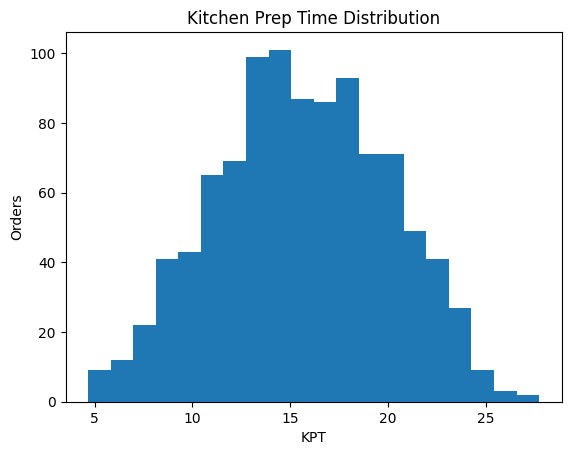

In [31]:
import matplotlib.pyplot as plt

plt.hist(dataset["KPT"], bins=20)

plt.title("Kitchen Prep Time Distribution")

plt.xlabel("KPT")

plt.ylabel("Orders")

plt.show()

In [32]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

In [33]:
node_positions = {

"A":(0,0),
"B":(1,0),
"C":(2,0),
"D":(3,0),
"E":(4,0),
"F":(5,0)

}

In [50]:
def draw_map(ax):

    # draw nodes
    for node,(x,y) in node_positions.items():
        ax.scatter(x,y)
        ax.text(x,y+0.05,node,ha='center')

    # draw edges
    for node in graph:
        for neighbor in graph[node]:
            x1,y1 = node_positions[node]
            x2,y2 = node_positions[neighbor]
            ax.plot([x1,x2],[y1,y2])

In [59]:
from matplotlib.animation import FuncAnimation
import matplotlib.pyplot as plt

def animate_delivery(route):

    fig, ax = plt.subplots()

    def update(frame):

        ax.clear()

        # draw map edges
        for node in graph:
            for neighbor in graph[node]:
                x1,y1 = node_positions[node]
                x2,y2 = node_positions[neighbor]
                ax.plot([x1,x2],[y1,y2], linestyle="--")

        # draw nodes
        for node,(x,y) in node_positions.items():
            ax.scatter(x,y)
            ax.text(x,y+0.05,node,ha='center')

        # highlight full route
        route_x = [node_positions[n][0] for n in route]
        route_y = [node_positions[n][1] for n in route]

        ax.plot(route_x, route_y, linewidth=3)

        # moving agent
        current_node = route[frame]
        x,y = node_positions[current_node]

        ax.scatter(x,y, s=300)

        # start marker
        sx,sy = node_positions[route[0]]
        ax.scatter(sx,sy,s=200)

        # destination marker
        dx,dy = node_positions[route[-1]]
        ax.scatter(dx,dy,s=200)

        ax.set_xlim(-1,6)
        ax.set_ylim(-1,1)

        ax.set_title("RelayIQ Smart Delivery Route")

    anim = FuncAnimation(fig, update, frames=len(route), interval=1200)

    plt.show()

    return anim

Optimal Route: ['C', 'D', 'E', 'F']


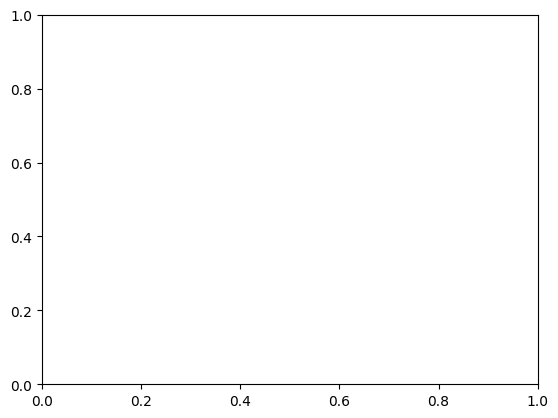

In [66]:
route = astar("C","F")

print("Optimal Route:", route)

anim = animate_delivery(route)

from IPython.display import HTML
HTML(anim.to_jshtml())

In [42]:
delivery_records = []

def generate_delivery_report(destination):

    pickup_agent = greedy_pickup_agent()

    route = astar(restaurant, destination)

    prep_time = round(predict_kpt(),2)

    delivery_time = len(route)*3 + prep_time

    order_id = random.randint(1000,9999)

    delivery_records.append({

        "Order_ID":order_id,

        "Pickup_Agent":pickup_agent,

        "Route":" → ".join(route),

        "Prep_Time_Min":prep_time,

        "Delivery_Time_Min":round(delivery_time,2)

    })

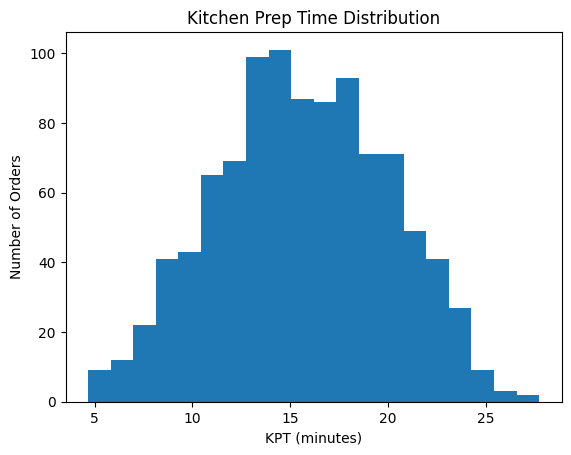

In [38]:
import matplotlib.pyplot as plt

plt.hist(dataset["KPT"], bins=20)

plt.title("Kitchen Prep Time Distribution")

plt.xlabel("KPT (minutes)")

plt.ylabel("Number of Orders")

plt.show()

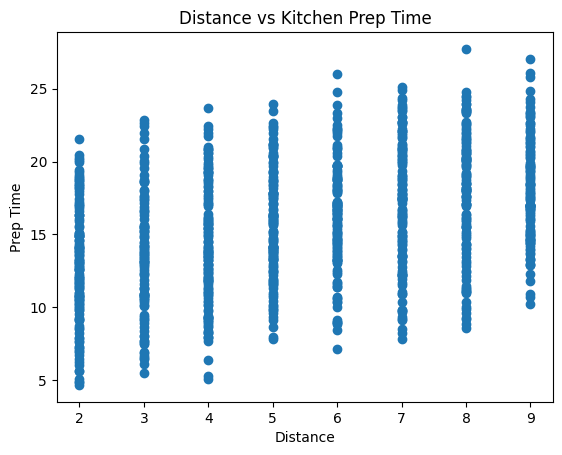

In [39]:
plt.scatter(dataset["distance"], dataset["KPT"])

plt.title("Distance vs Kitchen Prep Time")

plt.xlabel("Distance")

plt.ylabel("Prep Time")

plt.show()

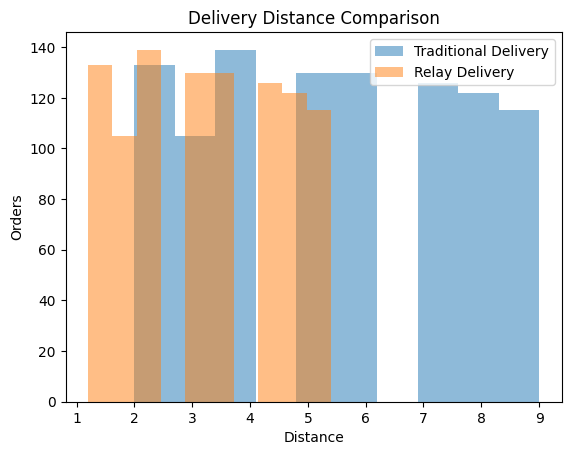

In [40]:
traditional_distance = dataset["distance"]

relay_distance = dataset["distance"] * 0.6

plt.figure()

plt.hist(traditional_distance, alpha=0.5, label="Traditional Delivery")

plt.hist(relay_distance, alpha=0.5, label="Relay Delivery")

plt.legend()

plt.title("Delivery Distance Comparison")

plt.xlabel("Distance")

plt.ylabel("Orders")

plt.show()

In [41]:
avg_traditional = dataset["distance"].mean()

avg_relay = (dataset["distance"] * 0.6).mean()

improvement = ((avg_traditional - avg_relay) / avg_traditional) * 100

print("Average Traditional Distance:", round(avg_traditional,2))
print("Average Relay Distance:", round(avg_relay,2))
print("Efficiency Improvement:", round(improvement,2), "%")

Average Traditional Distance: 5.46
Average Relay Distance: 3.28
Efficiency Improvement: 40.0 %


In [44]:
delivery_records = []

def generate_delivery_report(destination):

    pickup_agent = greedy_pickup_agent()

    route = astar(restaurant, destination)

    prep_time = round(predict_kpt(),2)

    delivery_time = len(route)*3 + prep_time

    order_id = random.randint(1000,9999)

    delivery_records.append({

        "Order_ID":order_id,

        "Pickup_Agent":pickup_agent,

        "Route":" → ".join(route),

        "Prep_Time_Min":prep_time,

        "Delivery_Time_Min":round(delivery_time,2)

    })

In [45]:
import random
import pandas as pd

def predict_kpt():

    items = random.randint(1,5)

    kitchen_load = random.randint(1,6)

    time_of_day = random.randint(1,3)

    distance = random.randint(2,9)

    features = pd.DataFrame({

        "number_of_items":[items],
        "kitchen_load":[kitchen_load],
        "time_of_day":[time_of_day],
        "distance":[distance]

    })

    kpt = model.predict(features)

    return kpt[0]

In [46]:
destinations = ["A","D","E","F","B"]

for d in destinations:

    generate_delivery_report(d)

In [47]:
report_df = pd.DataFrame(delivery_records)

report_df

,Order_ID,Pickup_Agent,Route,Prep_Time_Min,Delivery_Time_Min
0,3808,Agent1,C → B → A,12.80,21.80
1,7422,Agent1,C → D,12.51,18.51
2,7292,Agent1,C → D → E,18.78,27.78
3,5817,Agent1,C → D → E → F,21.59,33.59
4,6603,Agent1,C → B,15.80,21.80


In [49]:
report_df.to_csv("relay_delivery_report.csv", index=False)

print("Delivery report saved successfully")

Delivery report saved successfully


In [61]:
dataset.head(10)

,number_of_items,kitchen_load,time_of_day,distance,KPT
0,4,4,1,5,17.831493
1,5,4,2,3,18.599488
2,3,4,1,3,13.741727
3,5,4,1,7,21.206243
4,5,5,3,7,23.497702
5,2,5,3,6,16.457751
6,3,2,2,4,12.014663
7,3,1,1,6,10.558931
8,3,4,1,5,15.996492
9,5,2,1,6,16.829996


In [64]:
from IPython.display import HTML
HTML(anim.to_jshtml())